# 01 · Merchandising Performance

**Business question:** Which parts of H&M's assortment drive sales, how efficiently is
the range working, and where is the business relying on markdowns?

All SQL lives in `sql/`; this notebook loads each query by name (`hm.q("...")`) and
turns the results into charts. Run `python scripts/build_database.py` first.

**A note on prices.** H&M scaled the prices in this dataset, so absolute values are not
real currency. Everything below is expressed as shares, ratios or indexes, which are
unaffected by the scaling.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hm_analytics import HM, charts

charts.apply_style()
pd.options.display.float_format = "{:,.3f}".format
hm = HM()
print(f"Using database: {hm.path}")

Using database: C:\Users\Dewey\Desktop\fashion-retail-intelligence\fashion-retail-intelligence\data\hm.duckdb


## 1. The dataset at a glance

In [2]:
overview = hm.q("dataset_overview").T.rename(columns={0: "value"})
overview

,value
units_sold,31788324
baskets,9080179
purchasing_customers,1362281
registered_customers,1371980
articles_sold,104547
articles_in_catalog,105542
first_date,2018-09-20 00:00:00
last_date,2020-09-22 00:00:00


In [3]:
hm.q("data_quality_checks")

,check_name,value
0,Customers with no recorded age,0.012
1,Registered customers with no purchases,0.007
2,Catalog articles never sold,0.009
3,Units in non-category garment groups (Special ...,0.020
4,Transactions with no matching article,0.000


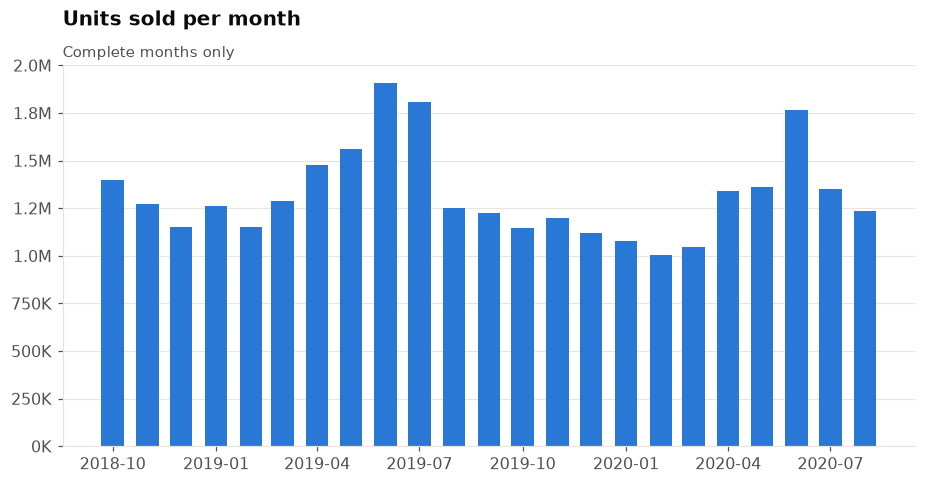

,month_start,active_customers,units_per_basket,online_unit_share
1,2018-10-01,274220,3.494,0.697
2,2018-11-01,274207,3.151,0.717
3,2018-12-01,254059,3.045,0.615
4,2019-01-01,242024,3.589,0.738
5,2019-02-01,238992,3.417,0.674
6,2019-03-01,244166,3.572,0.719
7,2019-04-01,260875,3.827,0.700
8,2019-05-01,271554,3.806,0.685
9,2019-06-01,305190,4.057,0.703
10,2019-07-01,296683,3.916,0.680


In [4]:
monthly = hm.q("monthly_kpis")
complete = monthly[monthly.is_complete_month]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(complete.month_start, complete.units, width=20, color=charts.ACCENT)
ax.set_title("Units sold per month")
charts.subtitle(ax, "Complete months only")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v / 1e6:.1f}M" if v >= 1e6 else f"{v / 1e3:.0f}K"))
ax.grid(axis="x", visible=False)
charts.save(fig, "01_monthly_units")
plt.show()

complete[["month_start", "active_customers", "units_per_basket", "online_unit_share"]]

## 2. Where do sales come from?

**Productivity index** = a garment group's share of revenue ÷ its share of the
articles sold. Above 1.0 means the group earns more than its share of the range;
below 1.0 means it takes up more of the assortment than its sales justify.

Garment-group comparisons in this notebook leave out "Special Offers" (a promotion
bucket) and "Unknown" (no label), which are not product categories. Together they are
under 2% of units (see the data quality checks above).

In [5]:
index_groups = hm.q("performance_by_index_group")
index_groups

,index_group_name,units,revenue,revenue_share,unit_share,articles_sold,price_index
0,Ladieswear,20415260,"587,272.173",0.664,0.642,39356,1.034
1,Divided,7138254,"189,270.043",0.214,0.225,15050,0.953
2,Menswear,1771053,"48,715.637",0.055,0.056,12457,0.988
3,Sport,1246408,"35,865.523",0.041,0.039,3381,1.034
4,Baby/Children,1217349,"23,522.598",0.027,0.038,34303,0.694


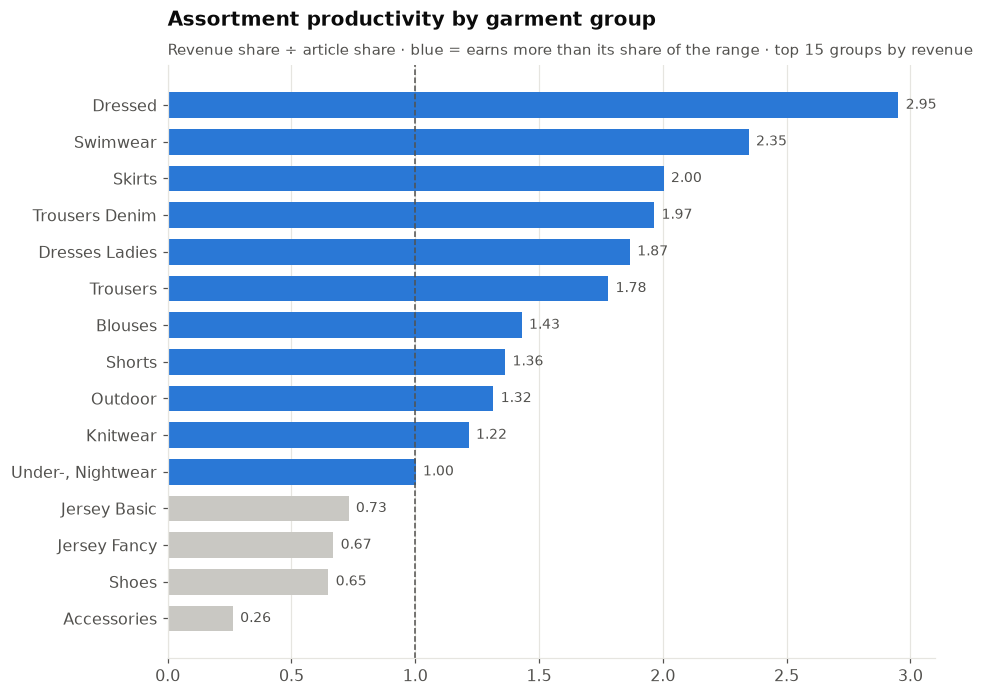

,garment_group_name,revenue_share,article_share,productivity_index,price_index
0,Jersey Fancy,0.143,0.213,0.669,0.851
1,Trousers,0.119,0.067,1.780,1.242
2,Dresses Ladies,0.091,0.049,1.867,1.300
3,Knitwear,0.090,0.074,1.216,1.159
4,Blouses,0.083,0.058,1.430,1.020
5,"Under-, Nightwear",0.074,0.074,1.002,0.770
6,Swimwear,0.066,0.028,2.347,0.796
7,Trousers Denim,0.061,0.031,1.965,1.459
8,Jersey Basic,0.059,0.081,0.731,0.558
9,Outdoor,0.058,0.044,1.316,2.509


In [6]:
garment = hm.q("performance_by_garment_group")

fig, ax = plt.subplots(figsize=(9, 7))
top = garment.nlargest(15, "revenue")
order = top.sort_values("productivity_index", ascending=False)
charts.barh(ax, order.garment_group_name, order.productivity_index,
            highlight=set(order.loc[order.productivity_index >= 1, "garment_group_name"]), fmt="{:.2f}")
ax.axvline(1, color=charts.TEXT_SECONDARY, linewidth=1, linestyle="--")
ax.set_title("Assortment productivity by garment group")
charts.subtitle(ax, "Revenue share ÷ article share · blue = earns more than its share of the range · top 15 groups by revenue")
charts.save(fig, "01_garment_group_productivity")
plt.show()

garment[["garment_group_name", "revenue_share", "article_share", "productivity_index", "price_index"]]

In [7]:
hm.q("top_product_types").head(15)

,product_type_name,product_group_name,units,revenue,revenue_share,articles_sold,price_index
0,Trousers,Garment Lower body,4217017,"150,908.046",0.171,11060,1.286
1,Dress,Garment Full body,3238428,"118,185.797",0.134,10266,1.311
2,Sweater,Garment Upper body,2783274,"80,732.983",0.091,9173,1.042
3,Blouse,Garment Upper body,1504868,"42,424.630",0.048,3941,1.013
4,Jacket,Garment Upper body,600157,"40,422.762",0.046,3865,2.420
5,Skirt,Garment Lower body,934338,"33,230.477",0.038,2677,1.278
6,Top,Garment Upper body,1583408,"32,120.534",0.036,4104,0.729
7,Bra,Underwear,1335233,"31,987.637",0.036,2197,0.861
8,T-shirt,Garment Upper body,2203750,"30,274.877",0.034,7873,0.494
9,Shorts,Garment Lower body,1152513,"26,973.206",0.030,3937,0.841


## 3. How concentrated are sales?

A long tail of slow-selling articles ties up design, buying and inventory budget.
The Pareto curve shows how few articles account for most revenue.

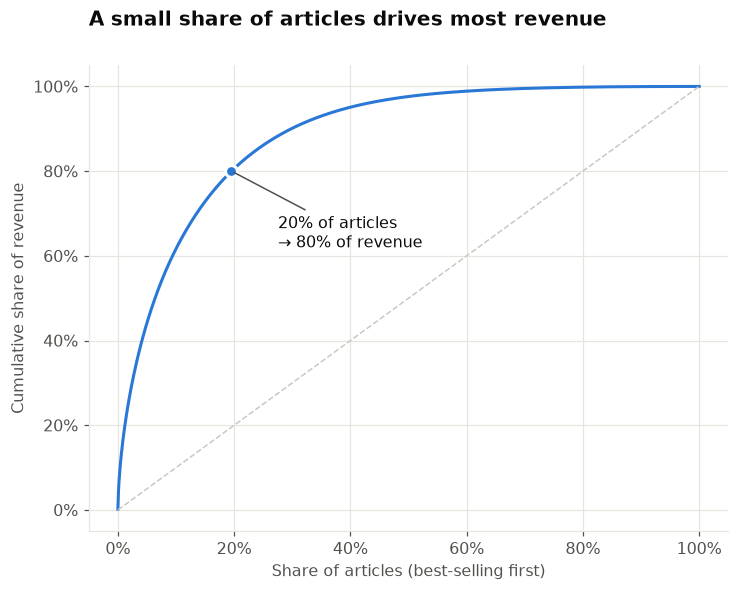

6.4% of articles generate 50% of revenue
19.5% of articles generate 80% of revenue
The top 10% of articles generate 61.7% of revenue
The bottom half of articles generate 2.4% of revenue


In [8]:
pareto = hm.q("article_pareto_curve")
summary = hm.q("pareto_summary").iloc[0]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(pareto.cum_article_share, pareto.cum_revenue_share, color=charts.ACCENT)
ax.plot([0, 1], [0, 1], color=charts.MUTED, linewidth=1, linestyle="--")
x80 = summary.article_share_for_80pct_revenue
ax.scatter([x80], [0.8], s=60, color=charts.ACCENT, zorder=3, edgecolor="white", linewidth=2)
ax.annotate(f"{x80:.0%} of articles\n→ 80% of revenue", (x80, 0.8), xytext=(x80 + 0.08, 0.62),
            color=charts.TEXT, arrowprops=dict(arrowstyle="-", color=charts.TEXT_SECONDARY))
charts.pct_axis(ax, "x")
charts.pct_axis(ax, "y")
ax.set_xlabel("Share of articles (best-selling first)")
ax.set_ylabel("Cumulative share of revenue")
ax.set_title("A small share of articles drives most revenue")
charts.save(fig, "01_pareto_curve")
plt.show()

print(f"{summary.article_share_for_50pct_revenue:.1%} of articles generate 50% of revenue")
print(f"{summary.article_share_for_80pct_revenue:.1%} of articles generate 80% of revenue")
print(f"The top 10% of articles generate {summary.revenue_share_top_10pct_articles:.1%} of revenue")
print(f"The bottom half of articles generate {summary.revenue_share_bottom_50pct_articles:.1%} of revenue")

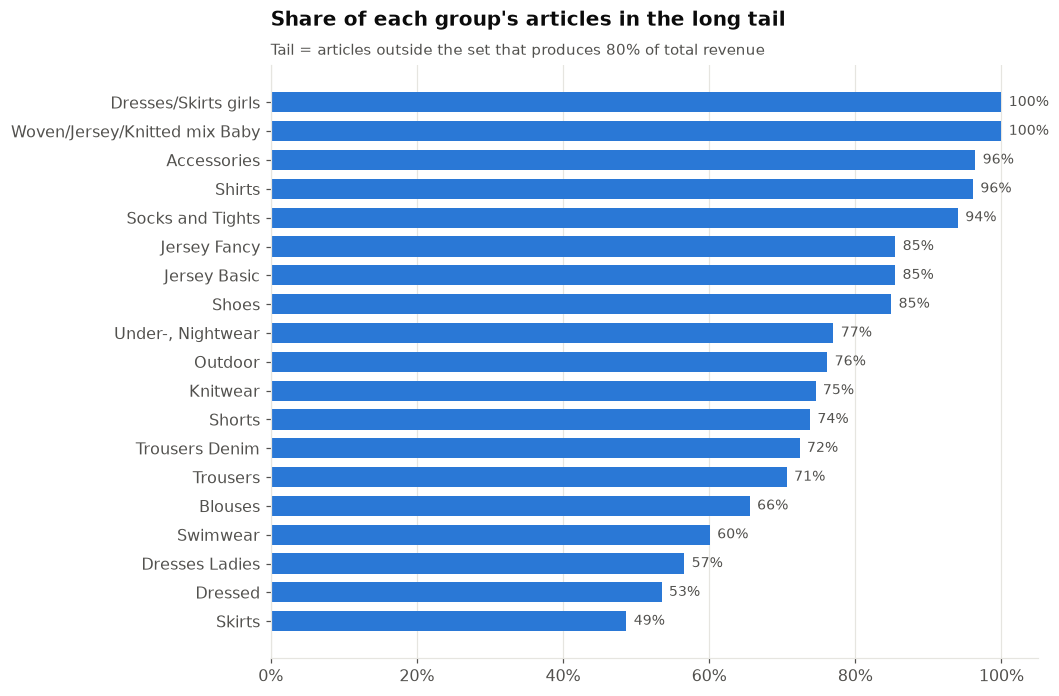

,garment_group_name,articles,tail_article_share,tail_revenue_share
0,Dresses/Skirts girls,1527,1.000,1.000
1,Woven/Jersey/Knitted mix Baby,1936,1.000,1.000
2,Accessories,11380,0.964,0.633
3,Shirts,2110,0.961,0.671
4,Socks and Tights,2252,0.940,0.284
5,Jersey Fancy,21265,0.855,0.277
6,Jersey Basic,8075,0.855,0.232
7,Shoes,5094,0.849,0.278
8,"Under-, Nightwear",7377,0.770,0.233
9,Outdoor,4415,0.762,0.137


In [9]:
tail = hm.q("tail_by_garment_group")
fig, ax = plt.subplots(figsize=(9, 7))
charts.barh(ax, tail.garment_group_name, tail.tail_article_share)
charts.pct_axis(ax, "x")
ax.set_title("Share of each group's articles in the long tail")
charts.subtitle(ax, "Tail = articles outside the set that produces 80% of total revenue")
charts.save(fig, "01_long_tail_by_group")
plt.show()
tail

## 4. Markdown dependence

The data has no promotion flag, so markdowns are inferred: each article's
**reference price** is its 90th-percentile selling price, and a unit sold at least
15% below that counts as marked down. This is a proxy — it can't separate a
clearance markdown from, say, a member discount.

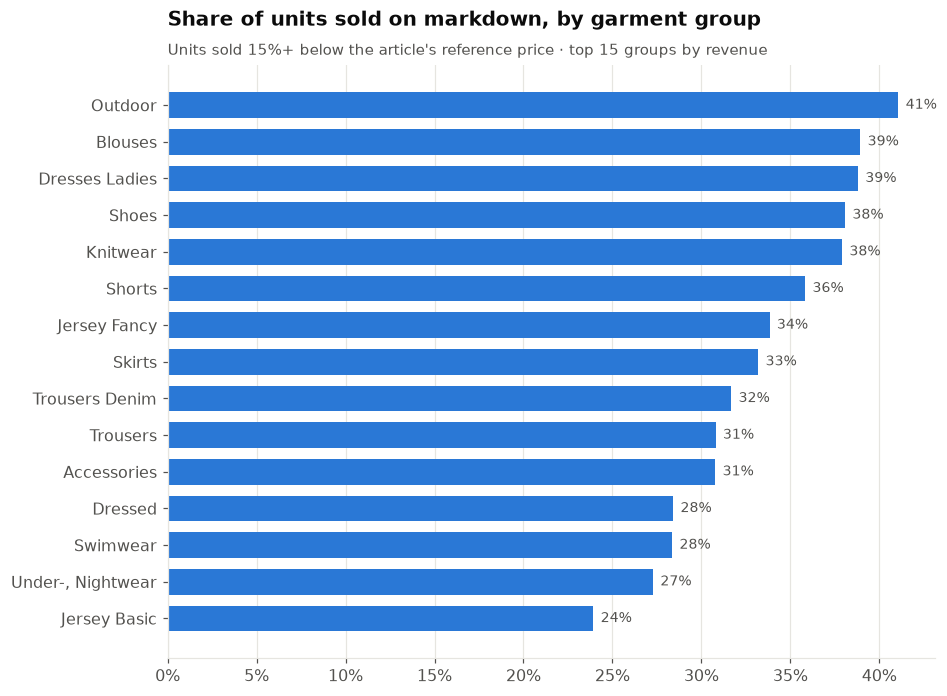

,garment_group_name,units,markdown_unit_share,avg_markdown_depth
2,Outdoor,715576,0.411,0.396
3,Blouses,2510441,0.389,0.426
4,Dresses Ladies,2147529,0.388,0.408
5,Shoes,729477,0.381,0.419
6,Knitwear,2392807,0.379,0.385
7,Shorts,736716,0.358,0.431
9,Jersey Fancy,5171611,0.338,0.408
10,Skirts,624822,0.332,0.402
12,Trousers Denim,1279886,0.317,0.380
13,Trousers,2953711,0.308,0.379


In [10]:
md = hm.q("markdown_by_garment_group")
top_groups = garment.nlargest(15, "revenue").garment_group_name
md_top = md[md.garment_group_name.isin(top_groups)].sort_values("markdown_unit_share", ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
charts.barh(ax, md_top.garment_group_name, md_top.markdown_unit_share)
charts.pct_axis(ax, "x")
ax.set_title("Share of units sold on markdown, by garment group")
charts.subtitle(ax, "Units sold 15%+ below the article's reference price · top 15 groups by revenue")
charts.save(fig, "01_markdown_by_group")
plt.show()
md_top

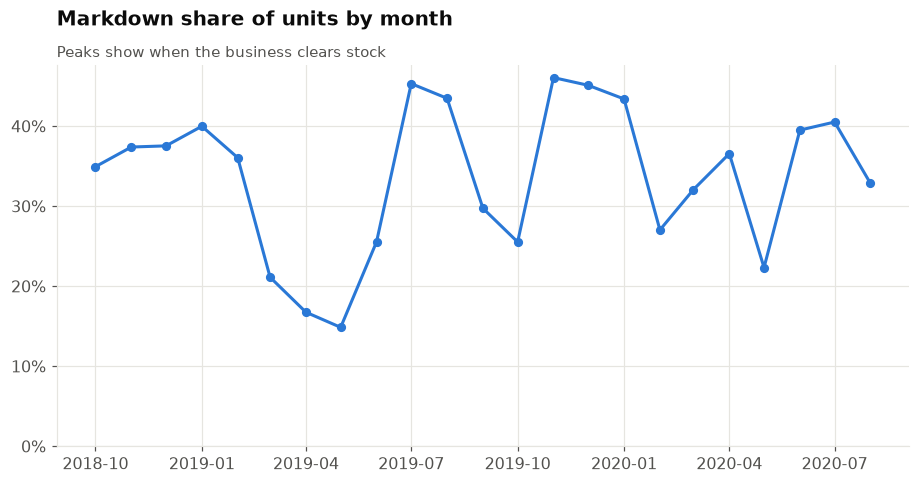

In [11]:
md_month = hm.q("markdown_by_month")
md_month = md_month[md_month.month_start.isin(complete.month_start)]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(md_month.month_start, md_month.markdown_unit_share, color=charts.ACCENT, marker="o", markersize=5)
charts.pct_axis(ax, "y")
ax.set_ylim(0, None)
ax.set_title("Markdown share of units by month")
charts.subtitle(ax, "Peaks show when the business clears stock")
charts.save(fig, "01_markdown_by_month")
plt.show()

## 5. Lifecycles and newness

In [12]:
hm.q("lifecycle_by_garment_group")

,garment_group_name,articles,median_selling_weeks,median_units_per_article,avg_units_per_article
0,Shorts,675,59.000,182.000,614.344
1,Swimwear,1420,50.000,707.500,"1,270.502"
2,Dresses Ladies,2112,49.000,504.500,688.743
3,Skirts,622,48.000,511.500,678.294
4,Blouses,2702,46.000,365.500,621.235
5,Trousers,3165,42.000,173.000,530.896
6,Trousers Denim,1414,42.000,99.000,447.854
7,Dressed,439,38.000,314.000,598.228
8,"Under-, Nightwear",3646,37.000,247.000,497.404
9,Knitwear,3453,35.000,105.000,366.496


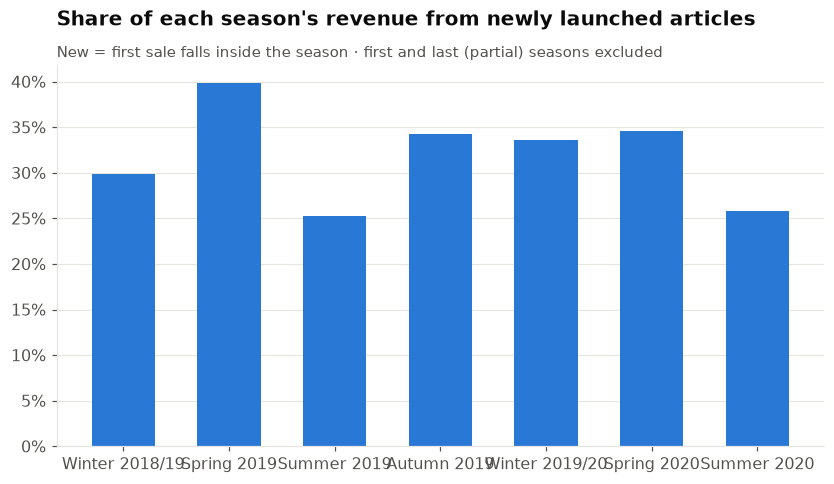

,season_start,season_label,articles_sold,new_articles,new_article_revenue_share
0,2018-12-01,Winter 2018/19,42484,10599,0.298
1,2019-03-01,Spring 2019,43803,10851,0.398
2,2019-06-01,Summer 2019,43540,8335,0.252
3,2019-09-01,Autumn 2019,40175,8022,0.343
4,2019-12-01,Winter 2019/20,42119,8272,0.336
5,2020-03-01,Spring 2020,38647,8801,0.346
6,2020-06-01,Summer 2020,42588,8048,0.259


In [13]:
newness = hm.q("new_vs_carryover_by_season")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(newness.season_label, newness.new_article_revenue_share, color=charts.ACCENT, width=0.6)
charts.pct_axis(ax, "y")
ax.grid(axis="x", visible=False)
ax.set_title("Share of each season's revenue from newly launched articles")
charts.subtitle(ax, "New = first sale falls inside the season · first and last (partial) seasons excluded")
charts.save(fig, "01_newness_by_season")
plt.show()
newness

## 6. Colour mix by season

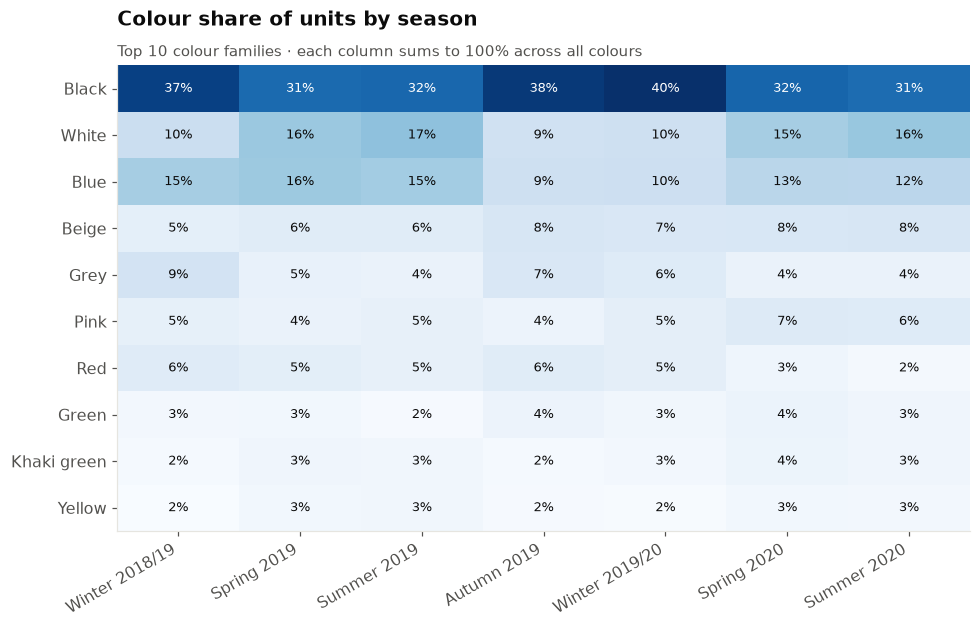

In [14]:
colours = hm.q("colour_mix_by_season")
top_colours = colours.groupby("perceived_colour_master_name").units.sum().nlargest(10).index
grid = (colours[colours.perceived_colour_master_name.isin(top_colours)]
        .pivot_table(index="perceived_colour_master_name", columns="season_start", values="unit_share")
        .reindex(top_colours))
labels = colours.drop_duplicates("season_start").set_index("season_start").season_label

fig, ax = plt.subplots(figsize=(10, 5.5))
im = ax.imshow(grid.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(grid.shape[1]), [labels[c] for c in grid.columns], rotation=30, ha="right")
ax.set_yticks(range(grid.shape[0]), grid.index)
ax.grid(False)
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        value = grid.values[i, j]
        ax.text(j, i, f"{value:.0%}", ha="center", va="center", fontsize=8.5,
                color="white" if value > np.nanmax(grid.values) * 0.6 else charts.TEXT)
ax.set_title("Colour share of units by season")
charts.subtitle(ax, "Top 10 colour families · each column sums to 100% across all colours")
charts.save(fig, "01_colour_mix_by_season")
plt.show()

## Findings

- **Concentration:** 6.4% of articles produce half of revenue and 19.5% produce 80%; the
  top 10% of articles alone take 62%, while the bottom 50% contribute just 2.4%. Range
  decisions at the top of the curve matter far more than those in the tail.
- **Productivity:** Dressed (2.95×), Swimwear (2.35×), Skirts (2.0×) and Denim (1.97×)
  earn well above their share of the range. Accessories (0.26×) hold 11% of articles
  for 3% of revenue, and 96% of Accessories articles sit in the long tail. Jersey Fancy
  is the biggest group by revenue (14%) but occupies 21% of articles, giving 0.67×.
- **Markdown exposure:** about 33% of units sell 15%+ below reference price. Exposure is
  highest in Socks and Tights (46%) and Outdoor (41%) and lowest in Jersey Basic (24%).
  Without stock data this flags where to review buy depth and pricing, not the cause.
- **Seasonal newness:** articles launched within the season account for 25–40% of that
  season's revenue. The share is highest in spring (40% in Spring 2019) and lowest in
  summer (25–26%), so summer revenue depends more on carry-over articles.